<a href="https://colab.research.google.com/github/RMPlaysMCYT/Corn-Detection-System/blob/main/python/Notebooks/Corn_Seeds_Detection_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Corn Seed Quality Detection System
This page contains the process of the corn seed quality detection system which means it shows on how we produce this datasets

## Imports

In [18]:
import tensorflow as tf
import keras
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [19]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Cropping Images and Processed ones

In [ ]:
import os
import shutil
import cv2
import numpy as np
from pathlib import Path

base_path = '/content/drive/MyDrive/CornSeeds/NewCornData'
output_path = '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data'

processed_folders = ['Healthy_Processed', 'Unhealthy_Processed']
for folder in processed_folders:
    os.makedirs(os.path.join(output_path, folder), exist_ok=True)

def zoom_and_resize_image(image_path, target_size=(256, 256), zoom_factor=1.2):
    """
    Zoom into the center of the image and resize to target size
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    h, w = img.shape[:2]

    new_h = int(h / zoom_factor)
    new_w = int(w / zoom_factor)

    start_h = (h - new_h) // 2
    start_w = (w - new_w) // 2

    cropped = img[start_h:start_h + new_h, start_w:start_w + new_w]

    resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_LANCZOS4)

    return resized

def remove_background_and_zoom(image_path, target_size=(256, 256)):
    """
    Advanced: Remove background and focus on the corn seed
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        x, y, w, h = cv2.boundingRect(largest_contour)

        padding = 20
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(img.shape[1] - x, w + 2 * padding)
        h = min(img.shape[0] - y, h + 2 * padding)

        cropped = img[y:y+h, x:x+w]

        resized = cv2.resize(cropped, target_size, interpolation=cv2.INTER_LANCZOS4)
        return resized

    return zoom_and_resize_image(image_path, target_size)
total_processed = 0
folder_mapping = {
    'Healthy': {
        'users': ['Ronnel', 'Marjorie'],
        'output': 'Healthy_Processed'
    },
    'Unhealthy': {
        'users': ['Rodriguez', 'Ronnel', 'Marjorie'],
        'output': 'Unhealthy_Processed'
    }
}

for source_category, config in folder_mapping.items():
    for user in config['users']:
        source_path = os.path.join(base_path, source_category, user)
        output_folder = os.path.join(output_path, config['output'])

        if os.path.exists(source_path):
            image_files = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']:
                image_files.extend(Path(source_path).glob(ext))
                image_files.extend(Path(source_path).glob(ext.upper()))

            all_files = os.listdir(source_path)
            for f in all_files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
                    if Path(os.path.join(source_path, f)) not in image_files:
                        image_files.append(Path(os.path.join(source_path, f)))

            print(f"Found {len(image_files)} images in {source_category}/{user}")

            for img_path in image_files:
                try:
                    processed_img = remove_background_and_zoom(str(img_path), target_size=(256, 256))

                    if processed_img is not None:
                        filename = f"{source_category}_{user}_{img_path.stem}.jpg"
                        output_path_full = os.path.join(output_folder, filename)

                        cv2.imwrite(output_path_full, processed_img)
                        total_processed += 1

                        if total_processed % 10 == 0:
                            print(f"Processed {total_processed} images...")
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")
        else:
            print(f"Warning: Path not found: {source_path}")

print(f"\n✅ Processing complete! Total images processed: {total_processed}")
print(f"📁 Output saved to: {output_path}")

print("\n📂 Folder structure created:")
for root, dirs, files in os.walk(output_path):
    level = root.replace(output_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for d in dirs:
            subindent = ' ' * 2 * (level + 1)
            print(f'{subindent}{d}/')

Found 464 images in Healthy/Ronnel
Processed 10 images...
Processed 20 images...
Processed 30 images...
Processed 40 images...
Processed 50 images...
Processed 60 images...
Processed 70 images...
Processed 80 images...
Processed 90 images...
Processed 100 images...
Processed 110 images...
Processed 120 images...
Processed 130 images...
Processed 140 images...
Processed 150 images...
Processed 160 images...
Processed 170 images...
Processed 180 images...
Processed 190 images...
Processed 200 images...
Processed 210 images...
Processed 220 images...
Processed 230 images...
Processed 240 images...
Processed 250 images...
Processed 260 images...
Processed 270 images...
Processed 280 images...
Processed 290 images...
Processed 300 images...
Processed 310 images...
Processed 320 images...
Processed 330 images...
Processed 340 images...
Processed 350 images...
Processed 360 images...
Processed 370 images...
Processed 380 images...
Processed 390 images...
Processed 400 images...
Processed 410 

## 64x64 Version

### Classification Loaded

In [21]:
import os
print(os.listdir('/content/drive/MyDrive/CornSeeds/NewCornData/processed_data'))

['Healthy_Processed', 'Unhealthy_Processed']


In [22]:
training_datagenerator1 = ImageDataGenerator(rescale = 1./255)

In [23]:
testing_set1 = training_datagenerator1.flow_from_directory(
    '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 1985 images belonging to 2 classes.


In [24]:
cnn_process1 = tf.keras.models.Sequential()

### FIRST LAYER

In [25]:
cnn_process1.add(
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=[64, 64, 3]
    )
)

cnn_process1.add(
    tf.keras.layers.MaxPool2D(
        pool_size = 2,
        strides = 2
    )
)

### SECOND LAYER

In [26]:
cnn_process1.add(
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
    )
)
cnn_process1.add(
    tf.keras.layers.MaxPool2D(
        pool_size = 2,
        strides = 2
    )
)

 ### PROCESSING

In [27]:
cnn_process1.add(tf.keras.layers.Flatten())

In [28]:
cnn_process1.add(tf.keras.layers.Dense(units=128, activation='relu'))
cnn_process1.add(tf.keras.layers.Dropout(0.5))

In [29]:
cnn_process1.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [30]:
cnn_process1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Found 1985 images belonging to 2 classes.
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 788s 12s/step - accuracy: 0.6227 - loss: 0.6652 - val_accuracy: 0.6126 - val_loss: 0.5958
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.7375 - loss: 0.5011 - val_accuracy: 0.7662 - val_loss: 0.4066
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.7879 - loss: 0.3888 - val_accuracy: 0.8846 - val_loss: 0.3258
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.8368 - loss: 0.3211 - val_accuracy: 0.9164 - val_loss: 0.2589
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - accuracy: 0.8751 - loss: 0.2831 - val_accuracy: 0.9315 - val_loss: 0.1950
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.9068 - loss: 0.2349 - val_accuracy: 0.8977 - val_loss: 0.3256
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.8947 - loss: 0.2288 - val_accuracy: 0.9290 - val_loss: 0.1800
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 170ms/step - a

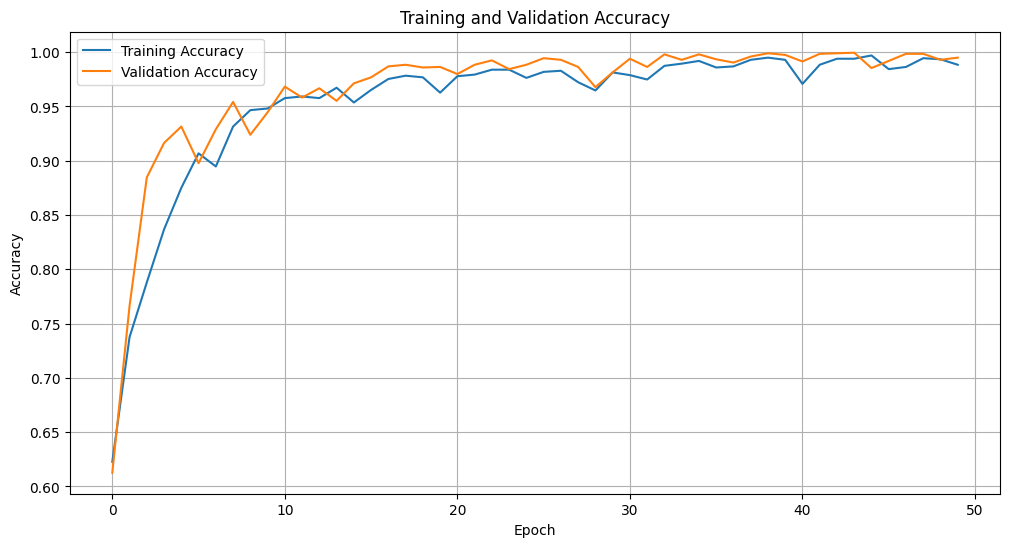

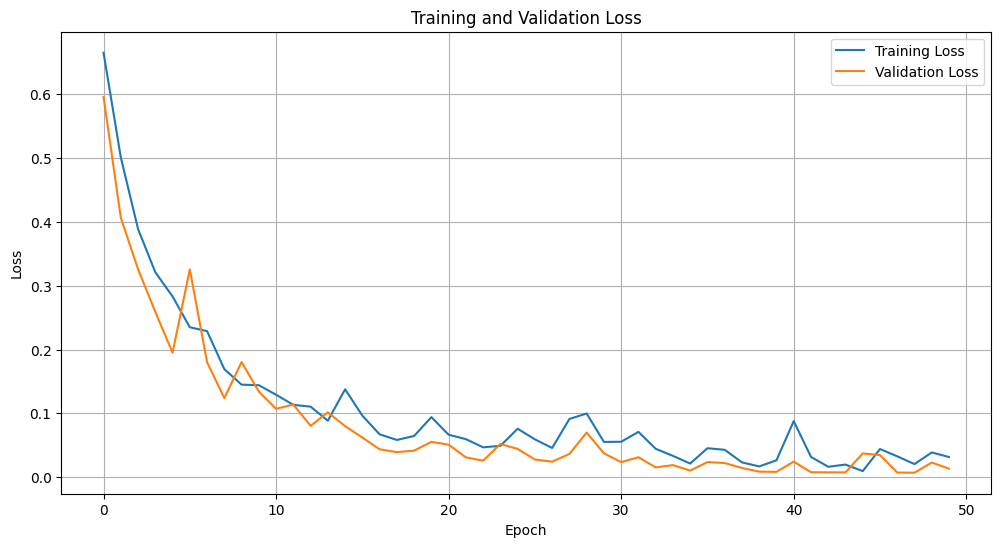

In [32]:
import matplotlib.pyplot as plt

#STEP 1
#INPUT_SHAPE = 64
training_set1 = training_datagenerator1.flow_from_directory(
    '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)
history = cnn_process1.fit(x=training_set1, validation_data=testing_set1, epochs=50)

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
cnn_process1.save('/content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_v0_0_2-stream.keras')

## MODEL TESTING (64x64)

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(cnn_process1)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open('/content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_v0_0_2-stream.tflite', 'wb') as f:
    f.write(tflite_model)

NameError: name 'cnn_process1' is not defined

In [ ]:
import tensorflow as tf

# Path to your saved model
model_path = '/content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_v0_0_1.keras'

# Load the model
print(f"Loading model from {model_path}...")
loaded_cnn_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

In [ ]:
import numpy as np
from keras.preprocessing import image
import os

# Directory for testing images
test_data_path = '/content/drive/MyDrive/CornSeeds/corn_data/labeled_data/'

# Setup generator for testing
prediction_datagen = image.ImageDataGenerator(rescale=1./255)
prediction_generator = prediction_datagen.flow_from_directory(
    test_data_path,
    target_size=(64, 64),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

# Run prediction using the LOADED model
predictions = loaded_cnn_model.predict(prediction_generator)

# Mapping and output
idx_to_class = {0: 'healthy', 1: 'unhealthy'}
filenames = prediction_generator.filenames

print("\n--- Predictions using loaded model ---")
for i, score in enumerate(predictions):
    predicted_class = idx_to_class[1 if score[0] > 0.5 else 0]
    image_name = os.path.basename(filenames[i])
    print(f"Image: {image_name}, Predicted: {predicted_class} (Confidence: {score[0]:.4f})")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import os
from pathlib import Path
from PIL import Image

# Path to the directory containing images to be tested
test_data_path = '/content/drive/MyDrive/CornSeeds/corn_data/labeled_data/'

# Create generator
prediction_datagen = image.ImageDataGenerator(rescale=1./255)

# Note: flow_from_directory will still attempt to index all files.
# We will use a safe prediction loop to handle potential corrupted files.
prediction_generator = prediction_datagen.flow_from_directory(
    test_data_path,
    target_size=(64, 64),
    batch_size=1, # Set to 1 for easier individual error handling
    class_mode=None,
    shuffle=False
)

filenames = prediction_generator.filenames
idx_to_class = {0: 'healthy', 1: 'unhealthy'}

print(f"\n--- Starting predictions for {len(filenames)} files ---")

# Iterate manually to catch UnidentifiedImageError on specific files
for i in range(len(filenames)):
    try:
        # Get the next batch (one image)
        img_batch = next(prediction_generator)

        # Predict
        prediction_score = cnn_process1.predict(img_batch, verbose=0)

        # Process result
        predicted_class_idx = 1 if prediction_score[0][0] > 0.5 else 0
        predicted_class_name = idx_to_class[predicted_class_idx]
        image_name = os.path.basename(filenames[i])

        print(f"Image: {image_name}, Predicted: {predicted_class_name} (Confidence: {prediction_score[0][0]:.4f})")

    except Exception as e:
        print(f"Skipping file {filenames[i]} due to error: {e}")
        continue

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import os
from pathlib import Path
from PIL import Image

# Path to the directory containing images to be tested
test_data_path = '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data/'

# Create generator
prediction_datagen = image.ImageDataGenerator(rescale=1./255)

# Note: flow_from_directory will still attempt to index all files.
# We will use a safe prediction loop to handle potential corrupted files.
prediction_generator = prediction_datagen.flow_from_directory(
    test_data_path,
    target_size=(64, 64),
    batch_size=1, # Set to 1 for easier individual error handling
    class_mode=None,
    shuffle=False
)

filenames = prediction_generator.filenames
idx_to_class = {0: 'healthy', 1: 'unhealthy'}

# Counters for statistics
healthy_count = 0
unhealthy_count = 0
processed_count = 0

print(f"\n--- Starting predictions for {len(filenames)} files ---")

# Iterate manually to catch UnidentifiedImageError on specific files
for i in range(len(filenames)):
    try:
        # Get the next batch (one image)
        img_batch = next(prediction_generator)

        # Predict
        prediction_score = cnn_process1.predict(img_batch, verbose=0)

        # Process result
        predicted_class_idx = 1 if prediction_score[0][0] > 0.5 else 0
        predicted_class_name = idx_to_class[predicted_class_idx]
        image_name = os.path.basename(filenames[i])

        # Update counters
        if predicted_class_idx == 0:
            healthy_count += 1
        else:
            unhealthy_count += 1
        processed_count += 1

        print(f"Image: {image_name}, Predicted: {predicted_class_name} (Confidence: {prediction_score[0][0]:.4f})")

    except Exception as e:
        print(f"Skipping file {filenames[i]} due to error: {e}")
        continue

# Display summary statistics
if processed_count > 0:
    healthy_percent = (healthy_count / processed_count) * 100
    unhealthy_percent = (unhealthy_count / processed_count) * 100

    print("\n" + "="*30)
    print("PREDICTION SUMMARY")
    print("="*30)
    print(f"Total seeds processed: {processed_count}")
    print(f"Healthy seeds:   {healthy_count} ({healthy_percent:.2f}%)")
    print(f"Unhealthy seeds: {unhealthy_count} ({unhealthy_percent:.2f}%)")
    print("="*30)
else:
    print("\nNo images were successfully processed.")

## 128x128 **Version**

### Classification Loaded

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/CornSeeds/NewCornData/processed_data'))

['Healthy_Processed', 'Unhealthy_Processed']


In [ ]:
training_datagenerator1 = ImageDataGenerator(rescale = 1./255)

In [ ]:
testing_set1 = training_datagenerator1.flow_from_directory(
    '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)

Found 1985 images belonging to 2 classes.


In [ ]:
cnn_process1 = tf.keras.models.Sequential()

### FIRST LAYER

In [ ]:
cnn_process1.add(
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
        input_shape=[128, 128, 3]
    )
)

cnn_process1.add(
    tf.keras.layers.MaxPool2D(
        pool_size = 2,
        strides = 2
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### SECOND LAYER

In [ ]:
cnn_process1.add(
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu',
    )
)
cnn_process1.add(
    tf.keras.layers.MaxPool2D(
        pool_size = 2,
        strides = 2
    )
)

### Processing (128x128)

In [ ]:
cnn_process1.add(tf.keras.layers.Flatten())

In [ ]:
cnn_process1.add(tf.keras.layers.Dense(units=128, activation='relu'))
cnn_process1.add(tf.keras.layers.Dropout(0.5))

In [ ]:
cnn_process1.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [ ]:
cnn_process1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Found 1985 images belonging to 2 classes.
Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.6564 - loss: 0.6180 - val_accuracy: 0.7647 - val_loss: 0.5182
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.7788 - loss: 0.4124 - val_accuracy: 0.8373 - val_loss: 0.3200
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.8458 - loss: 0.3118 - val_accuracy: 0.8997 - val_loss: 0.2594
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.8705 - loss: 0.2989 - val_accuracy: 0.8272 - val_loss: 0.2931
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.8846 - loss: 0.2787 - val_accuracy: 0.8277 - val_loss: 0.3826
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.8262 - loss: 0.3656 - val_accuracy: 0.9023 - val_loss: 0.2895
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.8892 - loss: 0.2482 - val_accuracy: 0.9259 - val_loss: 0.1993
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - ac

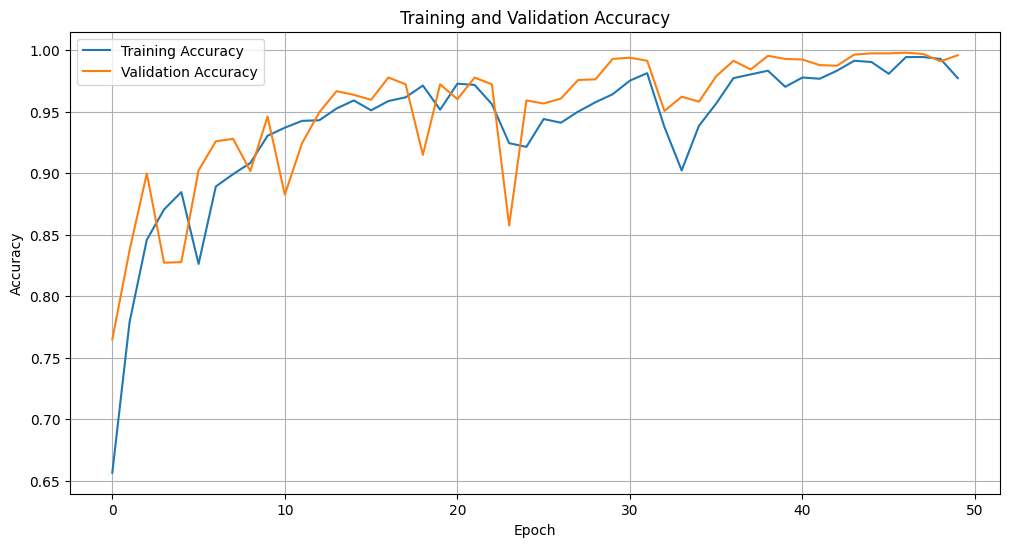

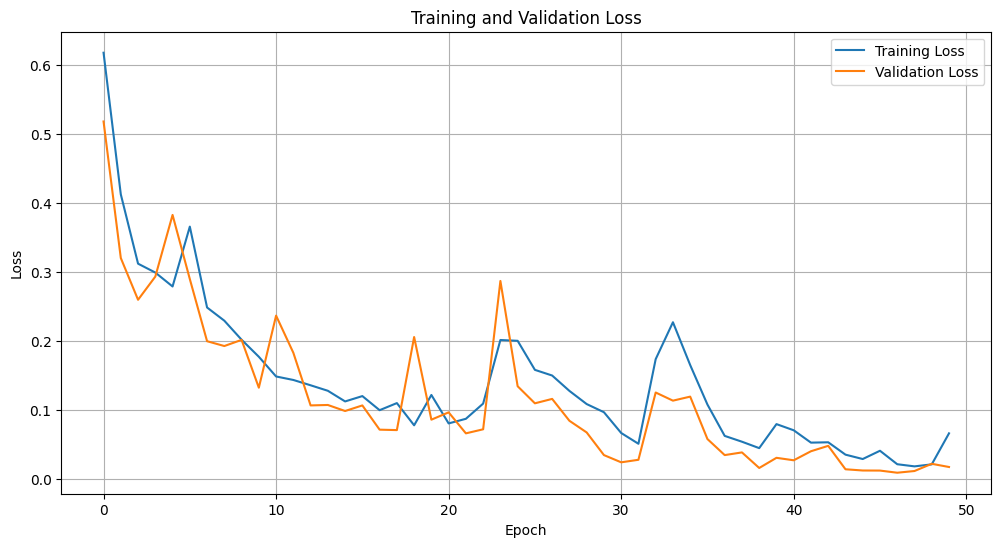

In [ ]:
import matplotlib.pyplot as plt

training_set1 = training_datagenerator1.flow_from_directory(
    '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary'
)
history = cnn_process1.fit(x=training_set1, validation_data=testing_set1, epochs=50)

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

RESULT AS OF 10:25AM PHT

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.6564 - loss: 0.6180 - val_accuracy: 0.7647 - val_loss: 0.5182

Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.7788 - loss: 0.4124 - val_accuracy: 0.8373 - val_loss: 0.3200

Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.8458 - loss: 0.3118 - val_accuracy: 0.8997 - val_loss: 0.2594

Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.8705 - loss: 0.2989 - val_accuracy: 0.8272 - val_loss: 0.2931

Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.8846 - loss: 0.2787 - val_accuracy: 0.8277 - val_loss: 0.3826

Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.8262 - loss: 0.3656 - val_accuracy: 0.9023 - val_loss: 0.2895

Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.8892 - loss: 0.2482 - val_accuracy: 0.9259 - val_loss: 0.1993

Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.8992 - loss: 0.2291 - val_accuracy: 0.9280 - val_loss: 0.1923

Epoch 9/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9083 - loss: 0.2015 - val_accuracy: 0.9018 - val_loss: 0.2012

Epoch 10/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9305 - loss: 0.1767 - val_accuracy: 0.9461 - val_loss: 0.1318

Epoch 11/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9370 - loss: 0.1481 - val_accuracy: 0.8826 - val_loss: 0.2364

Epoch 12/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9426 - loss: 0.1431 - val_accuracy: 0.9244 - val_loss: 0.1825

Epoch 13/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9431 - loss: 0.1353 - val_accuracy: 0.9496 - val_loss: 0.1061

Epoch 14/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9526 - loss: 0.1274 - val_accuracy: 0.9668 - val_loss: 0.1067

Epoch 15/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9592 - loss: 0.1119 - val_accuracy: 0.9637 - val_loss: 0.0980

Epoch 16/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9511 - loss: 0.1196 - val_accuracy: 0.9597 - val_loss: 0.1061

Epoch 17/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9587 - loss: 0.0992 - val_accuracy: 0.9778 - val_loss: 0.0709

Epoch 18/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9617 - loss: 0.1095 - val_accuracy: 0.9723 - val_loss: 0.0703

Epoch 19/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9713 - loss: 0.0773 - val_accuracy: 0.9149 - val_loss: 0.2054

Epoch 20/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9516 - loss: 0.1213 - val_accuracy: 0.9723 - val_loss: 0.0854

Epoch 21/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9728 - loss: 0.0800 - val_accuracy: 0.9602 - val_loss: 0.0960

Epoch 22/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.9718 - loss: 0.0867 - val_accuracy: 0.9778 - val_loss: 0.0656

Epoch 23/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9562 - loss: 0.1088 - val_accuracy: 0.9723 - val_loss: 0.0715

Epoch 24/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9244 - loss: 0.2010 - val_accuracy: 0.8574 - val_loss: 0.2867

Epoch 25/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9214 - loss: 0.1999 - val_accuracy: 0.9592 - val_loss: 0.1339

Epoch 26/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.9441 - loss: 0.1577 - val_accuracy: 0.9567 - val_loss: 0.1092

Epoch 27/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9411 - loss: 0.1495 - val_accuracy: 0.9607 - val_loss: 0.1156

Epoch 28/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9501 - loss: 0.1272 - val_accuracy: 0.9758 - val_loss: 0.0838

Epoch 29/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.9577 - loss: 0.1081 - val_accuracy: 0.9763 - val_loss: 0.0669

Epoch 30/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9642 - loss: 0.0963 - val_accuracy: 0.9929 - val_loss: 0.0340

Epoch 31/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9753 - loss: 0.0661 - val_accuracy: 0.9940 - val_loss: 0.0235

Epoch 32/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9814 - loss: 0.0505 - val_accuracy: 0.9914 - val_loss: 0.0272

Epoch 33/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9375 - loss: 0.1733 - val_accuracy: 0.9506 - val_loss: 0.1248

Epoch 34/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.9023 - loss: 0.2268 - val_accuracy: 0.9622 - val_loss: 0.1130

Epoch 35/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9385 - loss: 0.1647 - val_accuracy: 0.9582 - val_loss: 0.1189

Epoch 36/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9567 - loss: 0.1074 - val_accuracy: 0.9788 - val_loss: 0.0573

Epoch 37/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9773 - loss: 0.0619 - val_accuracy: 0.9914 - val_loss: 0.0340

Epoch 38/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.9804 - loss: 0.0534 - val_accuracy: 0.9844 - val_loss: 0.0379

Epoch 39/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.9834 - loss: 0.0441 - val_accuracy: 0.9955 - val_loss: 0.0153

Epoch 40/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9703 - loss: 0.0790 - val_accuracy: 0.9929 - val_loss: 0.0301

Epoch 41/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.9778 - loss: 0.0700 - val_accuracy: 0.9924 - val_loss: 0.0265

Epoch 42/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - accuracy: 0.9768 - loss: 0.0521 - val_accuracy: 0.9879 - val_loss: 0.0396

Epoch 43/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9834 - loss: 0.0526 - val_accuracy: 0.9874 - val_loss: 0.0474

Epoch 44/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.9914 - loss: 0.0347 - val_accuracy: 0.9965 - val_loss: 0.0134

Epoch 45/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.9904 - loss: 0.0283 - val_accuracy: 0.9975 - val_loss: 0.0117

Epoch 46/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9809 - loss: 0.0403 - val_accuracy: 0.9975 - val_loss: 0.0115

Epoch 47/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.9945 - loss: 0.0208 - val_accuracy: 0.9980 - val_loss: 0.0084

Epoch 48/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.9945 - loss: 0.0177 - val_accuracy: 0.9970 - val_loss: 0.0109

Epoch 49/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.9929 - loss: 0.0206 - val_accuracy: 0.9909 - val_loss: 0.0214

Epoch 50/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9773 - loss: 0.0656 - val_accuracy: 0.9960 - val_loss: 0.0167

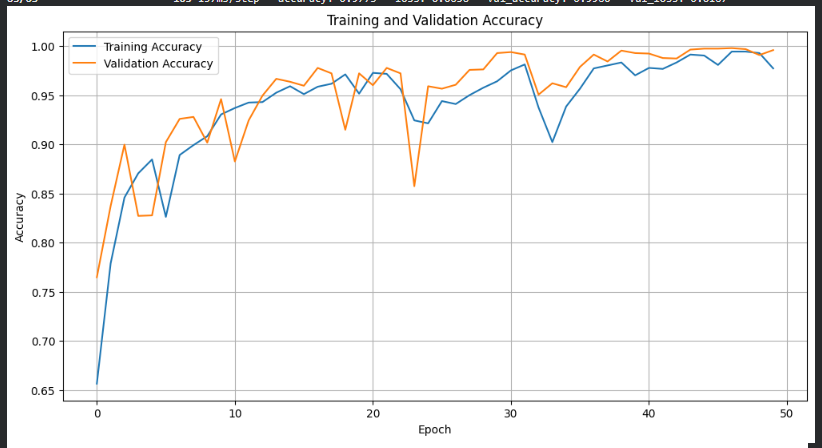

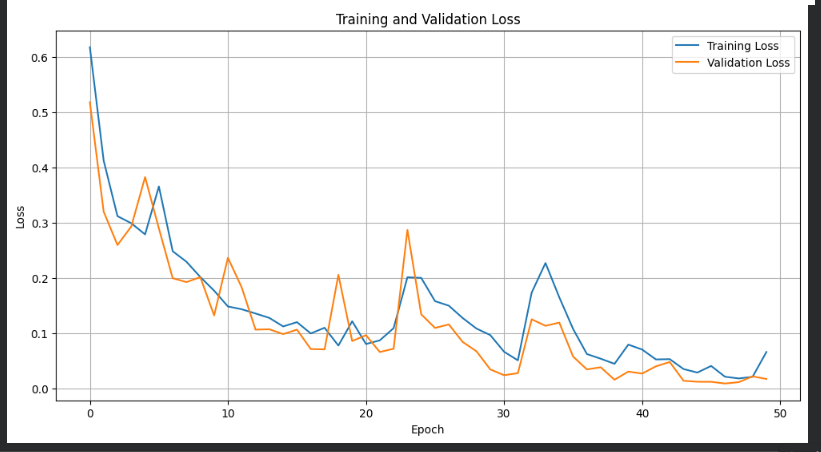

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cnn_process1.save('/content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_128x128_v0_0_1-stream.keras')

In [ ]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(cnn_process1)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open('/content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_128x128_v0_0_1-stream.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpx6htz5wy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140468558460304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468558461456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468558460880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468558462224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468525990160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468558460112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468525991696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140468525992464: TensorSpec(shape=(), dtype=tf.resource, name=None)


## MODEL TESTING (128x128)

In [ ]:
import tensorflow as tf

# Path to your saved model
model_path = '/content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_128x128_v0_0_1-stream.keras'

# Load the model
print(f"Loading model from {model_path}...")
loaded_cnn_model = tf.keras.models.load_model(model_path)
print("Model loaded successfully!")

Loading model from /content/drive/MyDrive/CornSeeds/OUTPUT_CapstoneProject_corn_seed_quality_detection_128x128_v0_0_1-stream.keras...
Model loaded successfully!


In [ ]:
import numpy as np
from keras.preprocessing import image
import os

# Directory for testing images
test_data_path = '/content/drive/MyDrive/CornSeeds/corn_data/labeled_data/'

# Setup generator for testing
prediction_datagen = image.ImageDataGenerator(rescale=1./255)
prediction_generator = prediction_datagen.flow_from_directory(
    test_data_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

# Run prediction using the LOADED model
predictions = loaded_cnn_model.predict(prediction_generator)

# Mapping and output
idx_to_class = {0: 'healthy', 1: 'unhealthy'}
filenames = prediction_generator.filenames

print("\n--- Predictions using loaded model ---")
for i, score in enumerate(predictions):
    predicted_class = idx_to_class[1 if score[0] > 0.5 else 0]
    image_name = os.path.basename(filenames[i])
    print(f"Image: {image_name}, Predicted: {predicted_class} (Confidence: {score[0]:.4f})")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import os
from pathlib import Path
from PIL import Image

# Path to the directory containing images to be tested
test_data_path = '/content/drive/MyDrive/CornSeeds/corn_data/labeled_data/'

# Create generator
prediction_datagen = image.ImageDataGenerator(rescale=1./255)

# Note: flow_from_directory will still attempt to index all files.
# We will use a safe prediction loop to handle potential corrupted files.
prediction_generator = prediction_datagen.flow_from_directory(
    test_data_path,
    target_size=(128, 128),
    batch_size=1, # Set to 1 for easier individual error handling
    class_mode=None,
    shuffle=False
)

filenames = prediction_generator.filenames
idx_to_class = {0: 'healthy', 1: 'unhealthy'}

print(f"\n--- Starting predictions for {len(filenames)} files ---")

# Iterate manually to catch UnidentifiedImageError on specific files
for i in range(len(filenames)):
    try:
        img_batch = next(prediction_generator)

        # Predict
        prediction_score = cnn_process1.predict(img_batch, verbose=0)

        # Process result
        predicted_class_idx = 1 if prediction_score[0][0] > 0.5 else 0
        predicted_class_name = idx_to_class[predicted_class_idx]
        image_name = os.path.basename(filenames[i])

        print(f"Image: {image_name}, Predicted: {predicted_class_name} (Confidence: {prediction_score[0][0]:.4f})")

    except Exception as e:
        print(f"Skipping file {filenames[i]} due to error: {e}")
        continue

Found 3007 images belonging to 3 classes.

--- Starting predictions for 3007 files ---
Image: aug_3_2036712710_WangDataa35.jpg, Predicted: unhealthy (Confidence: 1.0000)
Image: aug_3_203714993_WangDataa46.jpg, Predicted: healthy (Confidence: 0.0289)
Image: aug_3_203818312_WangDataa60.jpg, Predicted: healthy (Confidence: 0.0606)
Image: aug_3_2040426164_WangDataa43.jpg, Predicted: healthy (Confidence: 0.0010)
Image: aug_3_2040816385_WangDataa36.jpg, Predicted: unhealthy (Confidence: 1.0000)
Image: aug_3_2042297005_WangDataa41.jpg, Predicted: healthy (Confidence: 0.0578)
Skipping file healthy/aug_3_2043542508_WangDataa64.jpg due to error: cannot identify image file <_io.BytesIO object at 0x7ae304106610>
Image: healthy_1.jpg, Predicted: unhealthy (Confidence: 1.0000)
Image: healthy_10.jpg, Predicted: healthy (Confidence: 0.0006)
Image: healthy_100.jpg, Predicted: healthy (Confidence: 0.0152)
Image: healthy_1000.jpg, Predicted: healthy (Confidence: 0.0000)
Image: healthy_101.jpg, Predicted:

KeyboardInterrupt: 

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import os
from pathlib import Path
from PIL import Image

test_data_path = '/content/drive/MyDrive/CornSeeds/NewCornData/processed_data/'

prediction_datagen = image.ImageDataGenerator(rescale=1./255)

prediction_generator = prediction_datagen.flow_from_directory(
    test_data_path,
    target_size=(128, 128),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

filenames = prediction_generator.filenames
idx_to_class = {0: 'healthy', 1: 'unhealthy'}

healthy_count = 0
unhealthy_count = 0
processed_count = 0

print(f"\n--- Starting predictions for {len(filenames)} files ---")

for i in range(len(filenames)):
    try:
        img_batch = next(prediction_generator)

        prediction_score = cnn_process1.predict(img_batch, verbose=0)

        predicted_class_idx = 1 if prediction_score[0][0] > 0.5 else 0
        predicted_class_name = idx_to_class[predicted_class_idx]
        image_name = os.path.basename(filenames[i])

        if predicted_class_idx == 0:
            healthy_count += 1
        else:
            unhealthy_count += 1
        processed_count += 1

        print(f"Image: {image_name}, Predicted: {predicted_class_name} (Confidence: {prediction_score[0][0]:.4f})")

    except Exception as e:
        print(f"Skipping file {filenames[i]} due to error: {e}")
        continue

if processed_count > 0:
    healthy_percent = (healthy_count / processed_count) * 100
    unhealthy_percent = (unhealthy_count / processed_count) * 100

    print("\n" + "="*30)
    print("PREDICTION SUMMARY")
    print("="*30)
    print(f"Total seeds processed: {processed_count}")
    print(f"Healthy seeds:   {healthy_count} ({healthy_percent:.2f}%)")
    print(f"Unhealthy seeds: {unhealthy_count} ({unhealthy_percent:.2f}%)")
    print("="*30)
else:
    print("\nNo images were successfully processed.")

Found 1985 images belonging to 2 classes.

--- Starting predictions for 1985 files ---
Image: Healthy_Marjorie_IMG_7522.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7523.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7524.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7525.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7526.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7527.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7528.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7529.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7530.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7531.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7532.jpg, Predicted: healthy (Confidence: 0.0000)
Image: Healthy_Marjorie_IMG_7533.jpg, Predicted: health